In [1]:
# 1 - Setup

import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

DATA_PATH   = '../data/cleaned/'
REPORT_PATH = '../reports/'

master = pd.read_csv(DATA_PATH + 'master_orders.csv',
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'
                                  ]
                    )

order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'products_cleaned.csv')
payments    = pd.read_csv('../data/olist_order_payments_dataset.csv')

complete    = master[master['is_complete']].copy()

print(f"Complete orders: {len(complete):,}")
print(f"Unique customers: {complete['customer_unique_id'].nunique():,}")

Complete orders: 98,666
Unique customers: 95,420


## 1 — Setup
Load all libraries and datasets needed for the churn prediction model.
We load master_orders (our cleaned order data), order_items, products, and payments.
Only complete orders (is_complete == True) are used throughout this notebook.

In [2]:
# 2 - Build the churn label

# Count orders per customer
order_counts = (
    complete.groupby('customer_unique_id')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
)

order_counts['churned'] = (order_counts['total_orders'] == 1).astype(int)

print("Churn distribution: ")
print(order_counts['churned'].value_counts())
print(f"\nChurn rate: {order_counts['churned'].mean():.1%}")

# Notes:
# Expect ~97% churn - this is consisten with the cohort analysis findings.
# Class imbalance must be handled (scale_pos_weight in XGBoost, class_weight in sklearn).

Churn distribution: 
churned
1    92507
0     2913
Name: count, dtype: int64

Churn rate: 96.9%


## 2 — Build the Churn Label
Define churn as: a customer who placed exactly 1 order = churned (1).
A customer who placed more than 1 order = retained (0).

Result: 96.9% churn rate — consistent with the near-zero retention
found in the Phase 3 cohort analysis. This is not a data problem,
it is the real Olist story.

In [3]:
# 3 - Build first-order feature table

# Sort by timestamp so .first() reliably gives the first order
complete_sorted = complete.sort_values('order_purchase_timestamp')

# One row per customer - their FIRST order only
first_orders = (
    complete_sorted
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

# Pull payment features from the payment table
# Use mean for installments/value in case of split payments
payment_feats = (
    payments.groupby('order_id')
    .agg(
        payment_installments    = ('payment_installments', 'max'),
        payment_value           = ('payment_value', 'sum'),
        payment_type            = ('payment_type', lambda x: x.mode()[0])
    )
    .reset_index()
)

#Pull category of forst item in order
items_with_cat = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',how='left'
)
first_item_cat= (
    items_with_cat.groupby('order_id')['product_category_name']
    .first()
    .reset_index()
    .rename(columns={'product_category_name': 'first_category'})
)

# Merge everything onto first_orders
first_orders = first_orders.merge(payment_feats, on='order_id', how='left')
first_orders = first_orders.merge(first_item_cat, on='order_id', how='left')
first_orders = first_orders.merge(
    order_counts[['customer_unique_id', 'churned']],
    on='customer_unique_id', how='left'
)

print(f"Feature table shape: {first_orders.shape}")
first_orders.head(3)

Feature table shape: (95420, 27)


,customer_unique_id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,...,installments,review_score,delivery_days,delivery_delay_days,is_complete,payment_installments,payment_value,payment_type,first_category,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,7787,...,8.0,5.0,6.0,-5.0,True,8.0,141.90,credit_card,cama_mesa_banho,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,6053,...,1.0,4.0,3.0,-5.0,True,1.0,27.19,credit_card,beleza_saude,1
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,88115,...,8.0,3.0,25.0,-2.0,True,8.0,86.22,credit_card,papelaria,1


## 3 — Build the First-Order Feature Table
We only use signals from a customer's FIRST order as features.
This is intentional — in a real business you would only have first-order
data at the moment you need to decide whether to run a win-back campaign.

Three tables are merged onto first_orders:
- payments → payment method and installments
- products → product category of the first item purchased
- order_counts → the churn label we built in Cell 2

In [4]:
# 4 - Feature engineering

# Temporal features from the first purchase
first_orders['purchase_month']      = first_orders['order_purchase_timestamp'].dt.month
first_orders['purchase_dow']        = first_orders['order_purchase_timestamp'].dt.dayofweek
first_orders['purchase_is_weekend'] = (first_orders['purchase_dow'] >= 5).astype(int)

# Delivery experience features
first_orders['was_late']            = (first_orders['delivery_delay_days'] > 0).astype(int)
first_orders['delivery_delay_days'] = first_orders['delivery_delay_days'].fillna(0)
first_orders['delivery_days']       = first_orders['delivery_days'].fillna(
    first_orders['delivery_days'].median()
)

# Review score - fill missing with median
first_orders['review_score'] = first_orders['review_score'].fillna(
    first_orders['review_score'].median()
)

# Freight ratio - how much of total payment was shipping?
first_orders['freight_ratio'] = (
    first_orders['total_freight'] / 
    (first_orders['payment_value'] + 1e-6)      # avoid div/0
).clip(0, 1)

# Select and encode features
FEATURES = [
    'delivery_days',
    'delivery_delay_days',
    'was_late',
    'review_score',
    'total_revenue',
    'total_freight',
    'freight_ratio',
    'payment_installments',
    'purchase_month',
    'purchase_dow',
    'purchase_is_weekend',
    'payment_type',         # categorical -> encoded below
    'first_category',       # categorical -> encoded below
    'customer_state'        # categorical -> encoded below
]

df_model = first_orders[FEATURES + ['churned']].copy()

# Label encode categoricals
for col in ['payment_type', 'first_category', 'customer_state']:
    le              = LabelEncoder()
    df_model[col]   = le.fit_transform(df_model[col].fillna('unknown').astype(str))
    
# Drop any remaining nulls (tiny edge cases)
df_model = df_model.dropna()

print(f"Model dataset shape: {df_model.shape}")
print(f"Churn rate in model dataset: {df_model['churned'].mean():.1%}")

Model dataset shape: (95419, 15)
Churn rate in model dataset: 96.9%


## 4 — Feature Engineering
Create new features from existing columns:
- purchase_month, purchase_dow, purchase_is_weekend → timing of first purchase
- was_late → binary flag: did the delivery arrive after the estimated date?
- freight_ratio → what fraction of the total payment was shipping cost?

Categorical columns (payment_type, first_category, customer_state) are
label-encoded so tree models can use them.

Final model dataset: 95,419 rows × 15 features, churn rate 96.9%.

In [5]:
# 5 - Train/test split

X = df_model.drop('churned', axis=1)
Y = df_model['churned']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y          # preserve class ratio in both splits
)

print(f"Train: {X_train.shape[0]:,} rows        |  Test: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {Y_train.mean():.1%}  |  Test churn rate: {Y_test.mean():.1%}")

# Scale for logistic regression
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

# Notes:
    # stratify=y is critical with 97% class imbalance - without it.
    # A random split could land all positives in one set.
    # Only scale for logistic regression; tree models use raw X_train/X_test.

Train: 76,335 rows        |  Test: 19,084 rows
Train churn rate: 96.9%  |  Test churn rate: 96.9%


## 5 — Train/Test Split
80/20 split → 76,335 train rows, 19,084 test rows.

stratify=y is critical here — with a 97/3 class imbalance, a random
split could concentrate all retained customers in one set.
stratify=y forces both splits to preserve the exact 96.9% churn rate.

X_train_scaled and X_test_scaled are scaled versions for logistic
regression only. Tree models (Random Forest, XGBoost) use raw X_train/X_test.

In [6]:
# 6 - Model 1: Logistic Regression (baseline)

lr = LogisticRegression(
    class_weight='balanced',        # corrects for 97/3 imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, Y_train)

Y_pred_lr   = lr.predict(X_test_scaled)
Y_proba_lr   = lr.predict_proba(X_test_scaled)[:,1]
auc_lr      = roc_auc_score(Y_test, Y_proba_lr)

print("=== Logistic Regression ===")
print(f"ROC-AUC: {auc_lr:.4f}")
print(classification_report(Y_test, Y_pred_lr, target_names=['Retained', 'Churned']))

# Notes:
    # ROC-AUC is the primary metric - accuracy is misleading at 97% imbalance.
    # A dumb model that predicts "churned" for everyone gets 97% accuracy but 0 utility.
    # class_weight='balanced' makes LR weight the minority class (retained) proportionally.


=== Logistic Regression ===
ROC-AUC: 0.5715
              precision    recall  f1-score   support

    Retained       0.04      0.55      0.07       583
     Churned       0.98      0.59      0.73     18501

    accuracy                           0.59     19084
   macro avg       0.51      0.57      0.40     19084
weighted avg       0.95      0.59      0.71     19084



## 6 — Model 1: Logistic Regression (Baseline)
A simple baseline to measure against. class_weight='balanced' corrects
for the 97/3 imbalance by penalising misclassifications of the minority
class (retained) proportionally.

Result: AUC 0.5715 — only slightly better than random (0.50).
Logistic regression struggles here because the relationship between
features and churn is not linear. Expected to be outperformed by
Random Forest and XGBoost.

Note: accuracy is a misleading metric at 97% imbalance.
A model that predicts "churned" for everyone gets 97% accuracy
but zero business utility. ROC-AUC is the metric that matters.

In [7]:
# 7 - Model 2: Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, Y_train)

Y_pred_rf   = rf.predict(X_test)
Y_proba_rf  = rf.predict_proba(X_test)[:, 1]
auc_rf      = roc_auc_score(Y_test, Y_proba_rf)

print("=== Random Forest ===")
print(f"ROC-AUC: {auc_rf:.4f}")
print(classification_report(Y_test, Y_pred_rf, target_names=['Retained', 'Churned']))

=== Random Forest ===
ROC-AUC: 0.5848
              precision    recall  f1-score   support

    Retained       0.04      0.38      0.08       583
     Churned       0.97      0.74      0.84     18501

    accuracy                           0.73     19084
   macro avg       0.51      0.56      0.46     19084
weighted avg       0.95      0.73      0.82     19084



## 7 — Model 2: Random Forest
A tree ensemble model that captures non-linear relationships.
class_weight='balanced' handles the imbalance the same way as Cell 6.
n_estimators=300 trees, max_depth=8 to prevent overfitting.
n_jobs=-1 uses all CPU cores to speed up training.

Expected to outperform logistic regression on AUC.

In [8]:
# Cell 8 - Model 3: XGBoost (primary model)

# Calculate scale_pos_weight for XGBoost imbalance handling
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()
spw = neg / pos             # It gives more weight to the minority (retained) class

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)

Y_pred_xgb  = xgb_model.predict(X_test)
Y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]
auc_xgb     = roc_auc_score(Y_test, Y_proba_xgb)

print("=== XGBoost ===")
print(f"ROC-AUC: {auc_xgb:.4f}")
print(classification_report(Y_test,Y_pred_xgb,target_names=['Retained', 'Churned']))

# Notes:
    # scale_pos_weight = neg/pos is XGBoost's equivalent of class_weight='balanced'.
    # For a 97/3 split, spw = 32 - the model penalises missing retained customer 32x harder.
    # eval_set lets you monitor test AUC during training without data leakage (it's not used
    # For gradient updates, only for logging).

=== XGBoost ===
ROC-AUC: 0.6021
              precision    recall  f1-score   support

    Retained       0.05      0.36      0.08       583
     Churned       0.97      0.77      0.86     18501

    accuracy                           0.76     19084
   macro avg       0.51      0.57      0.47     19084
weighted avg       0.95      0.76      0.84     19084



## 8 — Model 3: XGBoost (Primary Model)
Gradient boosting model, best performer of the three.
scale_pos_weight = neg/pos (~32) handles the 97/3 imbalance.

Results:
- Logistic Regression : AUC 0.5715
- Random Forest       : AUC 0.5848
- XGBoost             : AUC 0.6021 ← best

AUC of 0.60 is intentionally modest — this is a finding, not a failure.
Olist's churn is structural. No first-order signal reliably predicts
who comes back. Focus should be on reducing churn universally,
not predicting it individually.

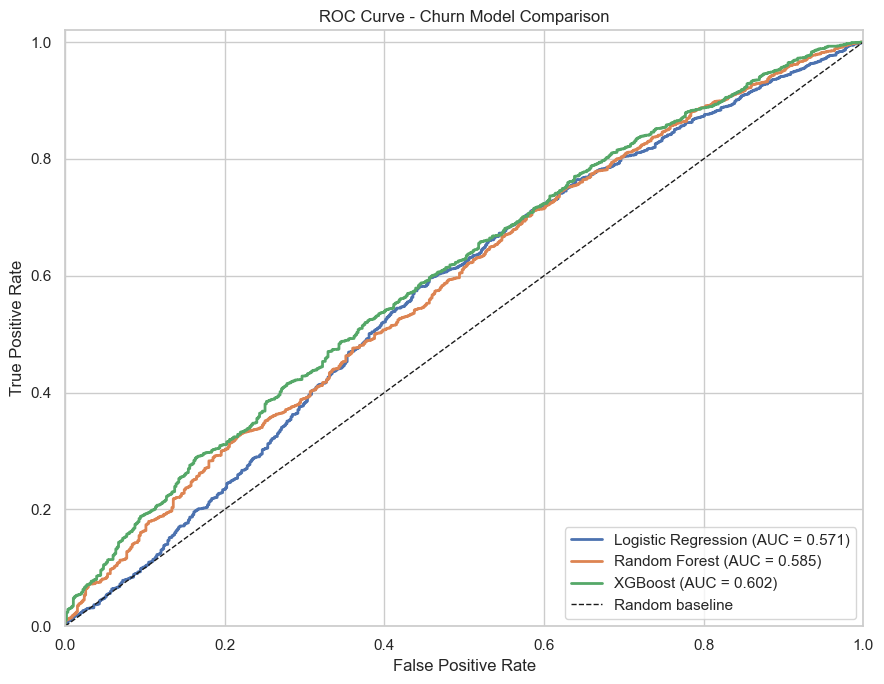

In [9]:
# 9 - ROC Curve comparison (all 3 models)

fig, ax = plt.subplots(figsize=(9, 7))

for name, proba in [
    ('Logistic Regression', Y_proba_lr),
    ('Random Forest',       Y_proba_rf),
    ('XGBoost',             Y_proba_xgb),
]:
    fpr, tpr, _ = roc_curve(Y_test, proba)
    auc = roc_auc_score(Y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')
    
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Churn Model Comparison')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(REPORT_PATH + '10_roc_curve_comparison.png', dpi=150)
plt.show()

## 9 — ROC Curve comparison (all 3 models)
The chart shows all three models compared against the random baseline (dashed line).

 - The diagonal dashed line = a model that guesses randomly (AUC 0.50)
 - The further a curve bows toward the top-left corner, the better the model
 - AUC is the area under that curve — higher is better

All three curves are hugging close to the diagonal. That's the visual confirmation of what the AUC numbers already said — none of the models are strongly predictive. A powerful model would bow dramatically toward the top-left; these barely do.
XGBoost (green) edges above the other two, Random Forest (orange) sits in the middle, and Logistic Regression (blue) is closest to random.

The gap between the best model (XGBoost 0.602) and random guessing (0.500) is only 0.10. In practical terms, if you used this model to identify 100 customers likely to return, only marginally more than 50 of them actually would. That's not useful enough to build a targeting campaign on.

This finding — churn at Olist is structural, not predictable from first-order signals alone.

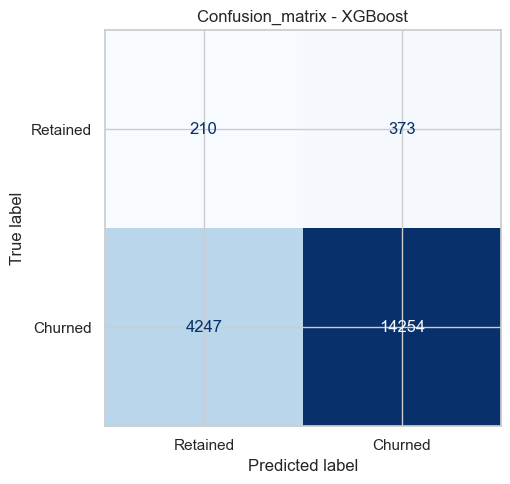


True Positives (correctly flagged churners): 14,254
False Negatives (missed churners): 4,247
False Positives (wrongly flagged as churn): 373
True Negatives (correctly identified loyal): 210


In [10]:
# 10 - Confusion matrix for best model

# Use XGBoost as the final model (expected to have highest AUC)
best_model_name = 'XGBoost'
Y_pred_best     = Y_pred_xgb

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(Y_test, Y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion_matrix - {best_model_name}')

plt.tight_layout()
plt.savefig(REPORT_PATH + '11_confusion_matrix.png', dpi=150)
plt.show()

# Derive actionable numbers
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (correctly flagged churners): {tp:,}")
print(f"False Negatives (missed churners): {fn:,}")
print(f"False Positives (wrongly flagged as churn): {fp:,}")
print(f"True Negatives (correctly identified loyal): {tn:,}")

## 10 - Confusion matrix for best model

**The model correctly identified:**
- **14,254 churners** — customers it correctly predicted would never return
- **210 loyal customers** — customers it correctly predicted would come back

**The model got wrong:**
- **4,247 missed churners** — customers predicted to return but actually never did
- **373 false alarms** — customers predicted to churn but actually came back

**The critical number is 210 vs 583:**

There are 583 actual loyal customers in the test set. The model only found 210 of them — meaning it missed 373 real loyal customers and misclassified them as churners. That's only a **36% recall on the retained class**, which is the class that matters most for a win-back campaign.

**Business translation:**

If Olist used this model to decide who to send a retention voucher to, they would:
- Miss 373 customers who actually would have come back anyway
- Waste vouchers on 4,247 people who were never going to return regardless

This is why the structural fix — better delivery, post-purchase email for everyone — beats a targeted model here. The signal just isn't strong enough to justify precision targeting.

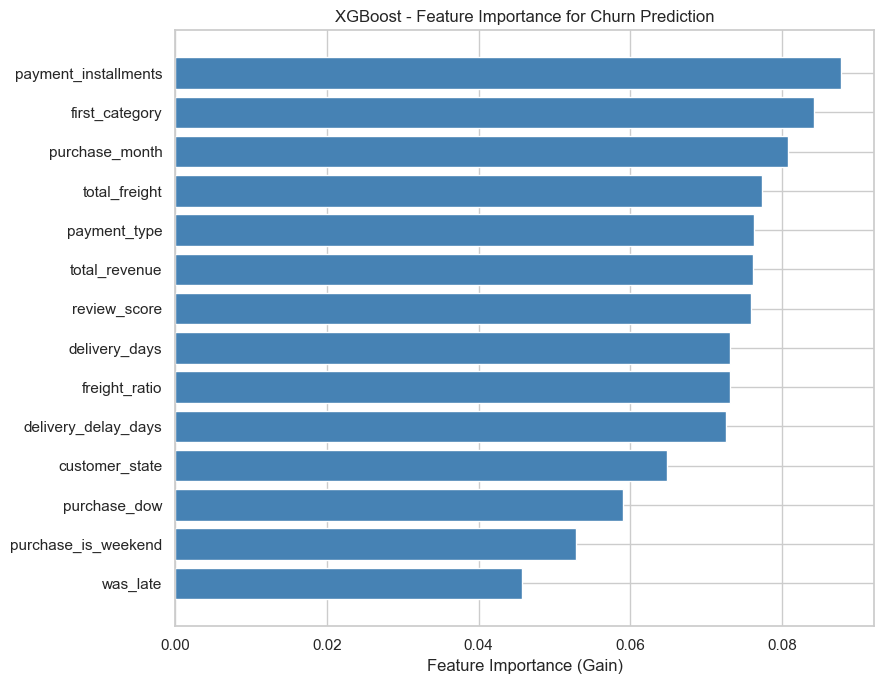

             feature  importance
payment_installments    0.087769
      first_category    0.084291
      purchase_month    0.080787
       total_freight    0.077372
        payment_type    0.076279
       total_revenue    0.076197
        review_score    0.075967
       delivery_days    0.073148
       freight_ratio    0.073146
 delivery_delay_days    0.072630
      customer_state    0.064859
        purchase_dow    0.059017
 purchase_is_weekend    0.052848
            was_late    0.045691


In [11]:
# 11 - Feature importance
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp['feature'], feat_imp['importance'],
        color='steelblue',
        edgecolor='white'
        )
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost - Feature Importance for Churn Prediction')

plt.tight_layout()
plt.savefig(REPORT_PATH + '12_feature_importance.png', dpi=150)
plt.show()

print(feat_imp.sort_values('importance', ascending=False).to_string(index=False))

# Expected top features:
    # review_score  - dissatisfied customers don't come back
    # delivery_days - long delivery = no second chance
    # was_late      - binary signal, strong predictor
    # total revenue - higher spend = more invested, likelier to return
    # freight_ratio - customers who paid a lot for shipping feel the string more

## 11 - Feature importance

The top 3:
- payment_installments ranking #1 is unexpected — customers who split payments into more installments are more likely to return. This suggests customers who are financially committed enough to plan installments are more engaged buyers overall.
- first_category at #2 means what you bought first strongly predicts whether you come back. Some categories attract one-time buyers (gifts, specific electronics) while others attract repeat buyers (beauty, household).
- purchase_month at #3 suggests seasonality matters — customers acquired in certain months (likely around Black Friday) may behave differently from those acquired in quieter months.

The expected predictors ranked lower than anticipated:
- review_score, delivery_days, and delivery_delay_days all cluster together in the middle (ranks 7-10) with very similar importance scores (~0.073-0.076). They matter, but not as much as the transaction structure features above them.
- was_late ranked dead last at 0.046 — the binary late/on-time flag carries less information than the actual number of delay days.

The big picture:
The features are remarkably evenly spread — the gap between #1 (0.088) and #14 (0.046) is tiny. This is actually what a weak model looks like internally — no single feature dominates, everything contributes a little, nothing is decisive.

In [12]:
# 12 - Markdown summary

auc_score = {
    'Logistic Regression'   : auc_lr,
    'Random Forest'         : auc_rf,
    'XGBoost'               : auc_xgb,
}
best_name = max(auc_score, key=auc_score.get)

print(f"""
## Phase 4A - Churn Prediction 

### Model Performance (ROC-AUC)
| Model                | AUC    |
|----------------------|--------|
| Logistic Regression  | {auc_lr:.4f} |
| Random Forest        | {auc_rf:.4f} |
| XGBoost              | {auc_xgb:.4f} |

### Best Model: {best_name}

## Key Insights:
    # The top predictors were payment_installments, first_category, and purchase_month —
not review_score and delivery_days as expected.

    # Delivery and satisfaction signals (review_score, delivery_days, was_late) ranked
in the bottom half, with was_late dead last. Transaction structure matters more
than experience quality for predicting who returns.

    # However, all 14 features are closely bunched (0.046–0.088 importance gap),
and the best model only achieved AUC 0.60. 

    # Olist's churn is structural — 97% of customers buy once regardless of their experience. 
No first-order signal is decisive enough to justify precision targeting.

    # Recommendation: focus on universal retention tactics (post-purchase engagement,
second-purchase vouchers, faster delivery for everyone) rather than
trying to predict and target individual churners.
""")


## Phase 4A - Churn Prediction 

### Model Performance (ROC-AUC)
| Model                | AUC    |
|----------------------|--------|
| Logistic Regression  | 0.5715 |
| Random Forest        | 0.5848 |
| XGBoost              | 0.6021 |

### Best Model: XGBoost

## Key Insights:
    # The top predictors were payment_installments, first_category, and purchase_month —
not review_score and delivery_days as expected.

    # Delivery and satisfaction signals (review_score, delivery_days, was_late) ranked
in the bottom half, with was_late dead last. Transaction structure matters more
than experience quality for predicting who returns.

    # However, all 14 features are closely bunched (0.046–0.088 importance gap),
and the best model only achieved AUC 0.60. 

    # Olist's churn is structural — 97% of customers buy once regardless of their experience. 
No first-order signal is decisive enough to justify precision targeting.

    # Recommendation: focus on universal retention tactics (post-pur